
# 2D waves, underwater islands, and diffraction

This notebook is a small **analysis-flavored numerical laboratory** for undergraduate students.  
We study a linear model for surface waves over variable depth and use it to visualize two complementary points of view:

1. **Time domain:** an incoming wavetrain travels from the left and hits a submerged island.
2. **Frequency domain:** for several incoming frequencies, we compute the corresponding steady state and animate one oscillation cycle.

The main ideas to watch for are:

- **variable depth changes wave speed**,
- **shallower water bends and focuses phase fronts**,
- **finite wavelength creates diffraction**, especially behind the island,
- **higher frequency** means shorter wavelength and more oscillatory scattering patterns.



## 1. A PDE model: linear shallow water over variable depth

Let

- $\eta(x,y,t)$ be the free-surface displacement,
- $v(x,y,t)$ the horizontal velocity,
- $H(x,y)$ the water depth,
- $g$ gravity.

A standard linearized shallow-water model is

$$
\eta_t + \nabla\cdot(Hv)=0,
\qquad
v_t + g\nabla \eta = 0.
$$

Differentiate the first equation in time and substitute $v_t=-g\nabla\eta$:

$$
\eta_{tt} = \nabla\cdot\big(gH(x,y)\nabla \eta\big).
$$

So the bathymetry enters through the variable coefficient

$$
c(x,y)^2 = gH(x,y).
$$

In constant depth, this reduces to the usual wave equation

$$
\eta_{tt} = c^2\Delta \eta,
\qquad c = \sqrt{gH}.
$$

For an **underwater island**, the water is shallower near one region, so $H$ is smaller there and the local wave speed is slower. That is the mechanism that bends phase fronts and creates scattering.



## 2. The numerical model used here

We solve a slightly modified driven/damped equation

$$
\eta_{tt} + \sigma(x,y)\eta_t = \nabla\cdot\big(c(x,y)^2\nabla \eta\big) + f(x,y,t),
$$

where

- $\sigma(x,y)\ge 0$ is a **sponge layer** near the boundary, used to absorb outgoing waves,
- $f$ is a narrow vertical source strip near the left side, designed to approximate a plane wave coming from the $-x$ direction.

For the time stepping we use a second-order centered explicit scheme.  If $L$ denotes the discrete divergence-form operator, then one update is

$$
\left(1+\tfrac12\sigma\,dt\right)u^{n+1}
=
2u^n - \left(1-\tfrac12\sigma\,dt\right)u^{n-1}
+ dt^2\big(Lu^n + f^n\big).
$$

For the steady state, we insert the monochromatic ansatz

$$
\eta(x,y,t)=\Re\big(U(x,y)e^{-i\omega t}\big),
$$

which leads to the damped Helmholtz-type problem

$$
\nabla\cdot\big(c(x,y)^2\nabla U\big) + \big(\omega^2 + i\omega\sigma(x,y)\big)U = -F.
$$

The notebook uses a **flat-bottom background medium** to define the incident field, then reconstructs the total field as

$$
U_{\mathrm{total}} = U_{\mathrm{incident}} + U_{\mathrm{scattered}}.
$$

This is a nice place where numerical PDEs and scattering ideas start to meet analysis.


In [1]:

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display, Markdown

sys.path.append(str(Path('.').resolve()))
from waves2d_underwater_island import *

plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 130
plt.rcParams['axes.grid'] = False
plt.rcParams['image.origin'] = 'lower'

workdir = Path('.')


In [2]:

# Geometry and bathymetry parameters.
grid = make_grid(nx=121, ny=81, Lx=12.0, Ly=7.0)
medium = make_medium(
    grid,
    island_center=(2.0, 0.0),
    island_height=0.62,
    radius_x=1.7,
    radius_y=1.9,
)

deep_speed = float(np.sqrt(np.max(medium.c2)))
dt = estimate_stable_dt(medium.c2, grid.dx, grid.dy)

print(f'grid: {grid.x.size} x {grid.y.size}')
print(f'dx = {grid.dx:.3f}, dy = {grid.dy:.3f}')
print(f'deep-water speed = {deep_speed:.3f}')
print(f'stable time step estimate dt <= {dt:.4f}')
print(f'depth range: {medium.depth.min():.3f} to {medium.depth.max():.3f}')


grid: 121 x 81
dx = 0.200, dy = 0.175
deep-water speed = 1.000
stable time step estimate dt <= 0.0593
depth range: 0.380 to 1.000



The simulation is **nondimensionalized** so that the far-field wave speed is about $1$.  
That makes the pictures easier to interpret: roughly speaking, one unit of time is one unit of travel distance in the deep-water region.


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guraltsev\AppData\Local\Temp\ipykernel_12832\2402699541.py:13: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title('Local speed $c(x,y)=\sqrt{H}$')
C:\Users\guraltsev\AppData\Local\Temp\ipykernel_12832\2402699541.py:19: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_title('Boundary sponge $\sigma(x,y)$')


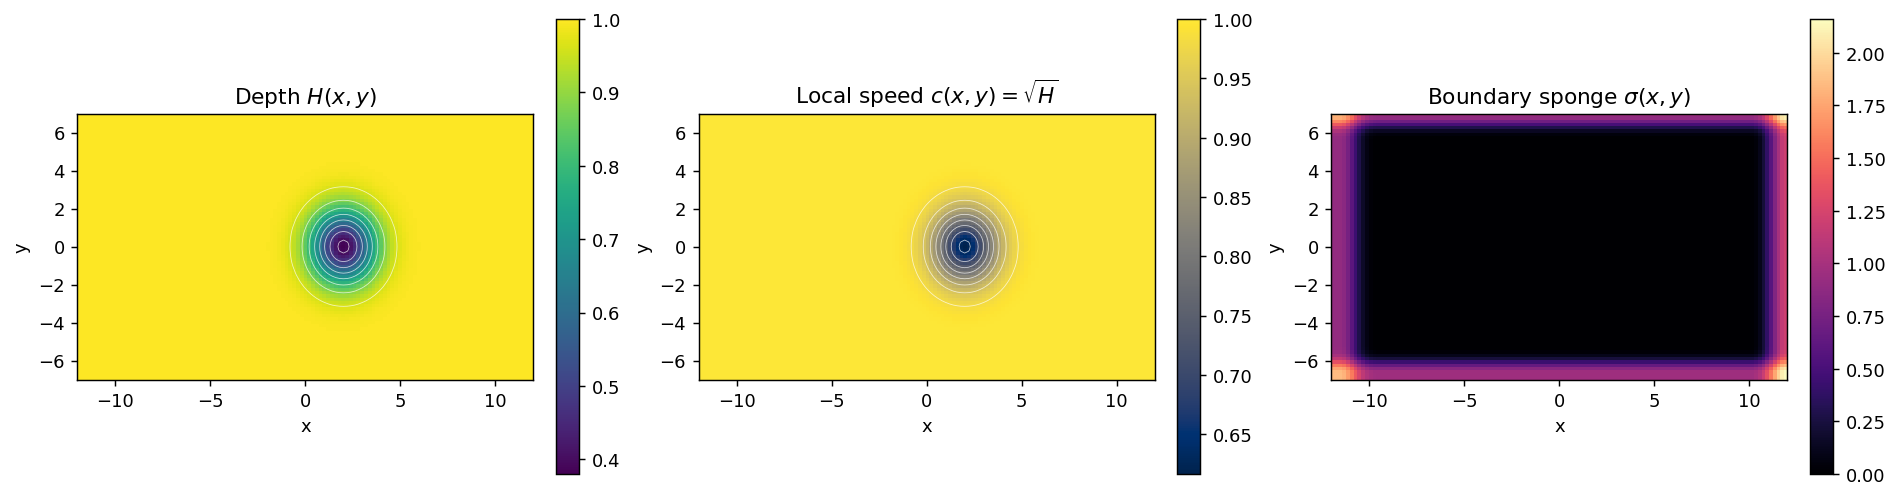

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), constrained_layout=True)
extent = [grid.x.min(), grid.x.max(), grid.y.min(), grid.y.max()]

im0 = axes[0].imshow(medium.depth, extent=extent, cmap='viridis')
axes[0].contour(grid.x, grid.y, medium.depth, colors='w', linewidths=0.45, alpha=0.7)
axes[0].set_title('Depth $H(x,y)$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(medium.speed, extent=extent, cmap='cividis')
axes[1].contour(grid.x, grid.y, medium.depth, colors='w', linewidths=0.45, alpha=0.7)
axes[1].set_title('Local speed $c(x,y)=\sqrt{H}$')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(medium.sigma, extent=extent, cmap='magma')
axes[2].set_title('Boundary sponge $\sigma(x,y)$')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
fig.colorbar(im2, ax=axes[2], shrink=0.85)

plt.show()



A few things to notice:

- the island is a **shallower bump** centered near $(2,0)$,
- the speed is therefore **smaller** over the island,
- the sponge layer is strongest near the outer boundary, where it suppresses artificial reflections.



## 3. Time-domain experiment: an incoming wavetrain from the left

We now launch a left-to-right wavetrain with angular frequency $\omega=1.9$.  
The source strip sits at $x\approx -7.6$, so there is room for a visibly incoming field before the wave reaches the island.


In [4]:

omega_td = 1.9
sim = run_time_domain(
    grid,
    medium,
    omega=omega_td,
    total_time=22.0,
    snapshot_stride=4,
    source_x0=-7.6,
)

print(sim.note)
print(f'{sim.snapshots.shape[0]} stored frames over times {sim.times[0]:.2f} to {sim.times[-1]:.2f}')


Damped explicit scheme with a strip source approximating a plane wave.
93 stored frames over times 0.00 to 21.81


<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
C:\Users\guraltsev\AppData\Local\Temp\ipykernel_12832\2360459231.py:20: SyntaxWarning: invalid escape sequence '\e'
  fig.colorbar(im, ax=axes, shrink=0.88, label='surface displacement $\eta$')


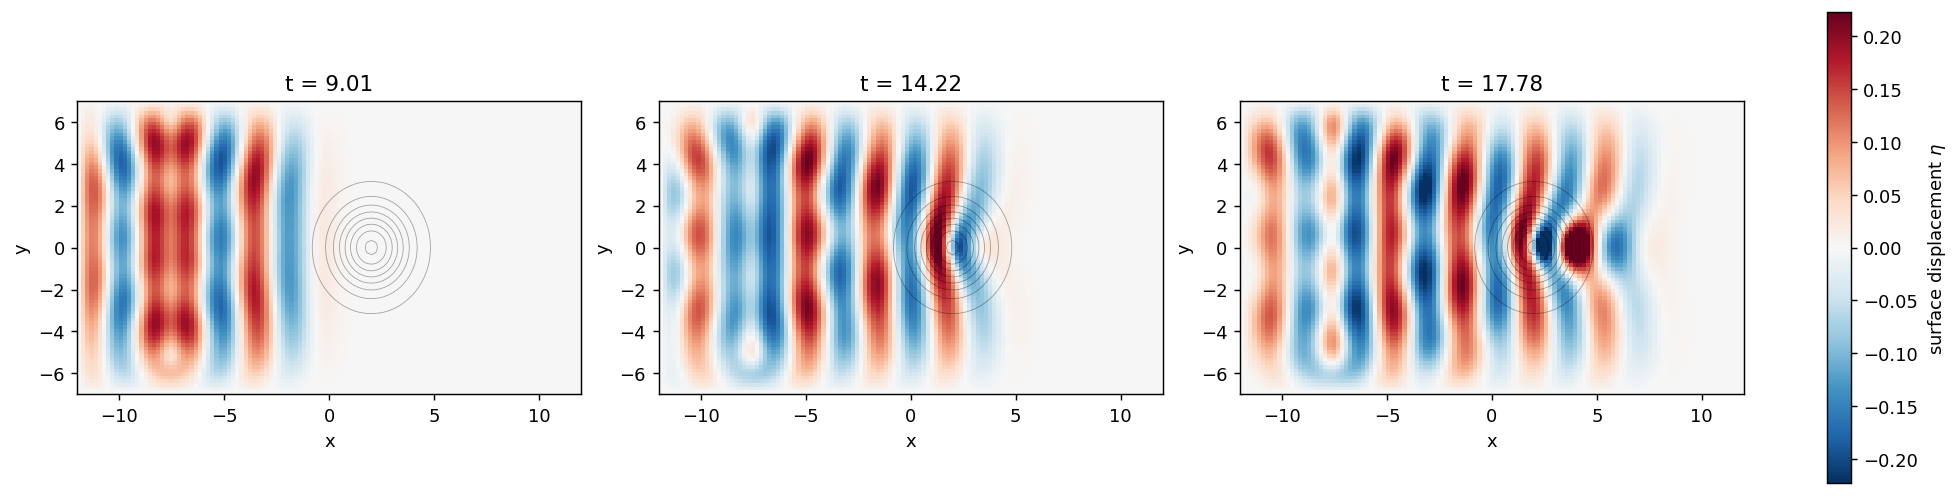

In [5]:

# Three representative times: before impact, during interaction, and after the wake forms.
target_times = [8.9, 14.2, 17.8]
frame_ids = [int(np.argmin(np.abs(sim.times - t))) for t in target_times]
vmax = float(np.quantile(np.abs(sim.snapshots), 0.995))

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2), constrained_layout=True)
for ax, idx in zip(axes, frame_ids):
    im = ax.imshow(
        sim.snapshots[idx],
        extent=extent,
        cmap='RdBu_r',
        vmin=-vmax,
        vmax=vmax,
    )
    ax.contour(grid.x, grid.y, medium.depth, colors='k', linewidths=0.45, alpha=0.35)
    ax.set_title(f't = {sim.times[idx]:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes, shrink=0.88, label='surface displacement $\eta$')
plt.show()



### What should we see?

As the wave hits the island,

- the phase fronts **slow down** over the shallower region,
- the fronts become **curved**,
- behind the island a **wake / diffraction pattern** develops,
- the field is not purely geometric-optics refraction: finite wavelength matters.

That last point is one of the easiest places to feel the transition from “PDE as formula” to “PDE as scattering phenomenon.”


In [6]:

time_movie = workdir / 'incoming_wave_diffraction.mp4'
if not time_movie.exists():
    save_time_animation(sim, time_movie, fps=12, dpi=80)

display(Video(str(time_movie), embed=True, html_attributes='controls loop'))



## 4. Frequency-domain steady states

Now we freeze the incoming frequency and solve the time-harmonic problem directly.

In the far field, the deep-water wavelength is approximately

$$
\lambda = \frac{2\pi c_0}{\omega},
\qquad c_0 \approx 1.
$$

So the frequencies below correspond roughly to the following wavelengths:

- $\omega=1.0$: long wave, large relative wavelength,
- $\omega=1.6$: intermediate,
- $\omega=2.2$: shorter and more oscillatory,
- $\omega=2.8$: shortest among the examples here.


In [7]:

omegas = [1.0, 1.6, 2.2, 2.8]
L = build_divergence_matrix(medium.c2, grid.dx, grid.dy)
solutions = [solve_steady_state(grid, medium, omega=w, L=L, source_x0=-7.6) for w in omegas]

for sol in solutions:
    wavelength = 2.0 * np.pi * deep_speed / sol.omega
    print(f'omega={sol.omega:.1f}  wavelength≈{wavelength:.2f}')


omega=1.0  wavelength≈6.28
omega=1.6  wavelength≈3.93
omega=2.2  wavelength≈2.86
omega=2.8  wavelength≈2.24


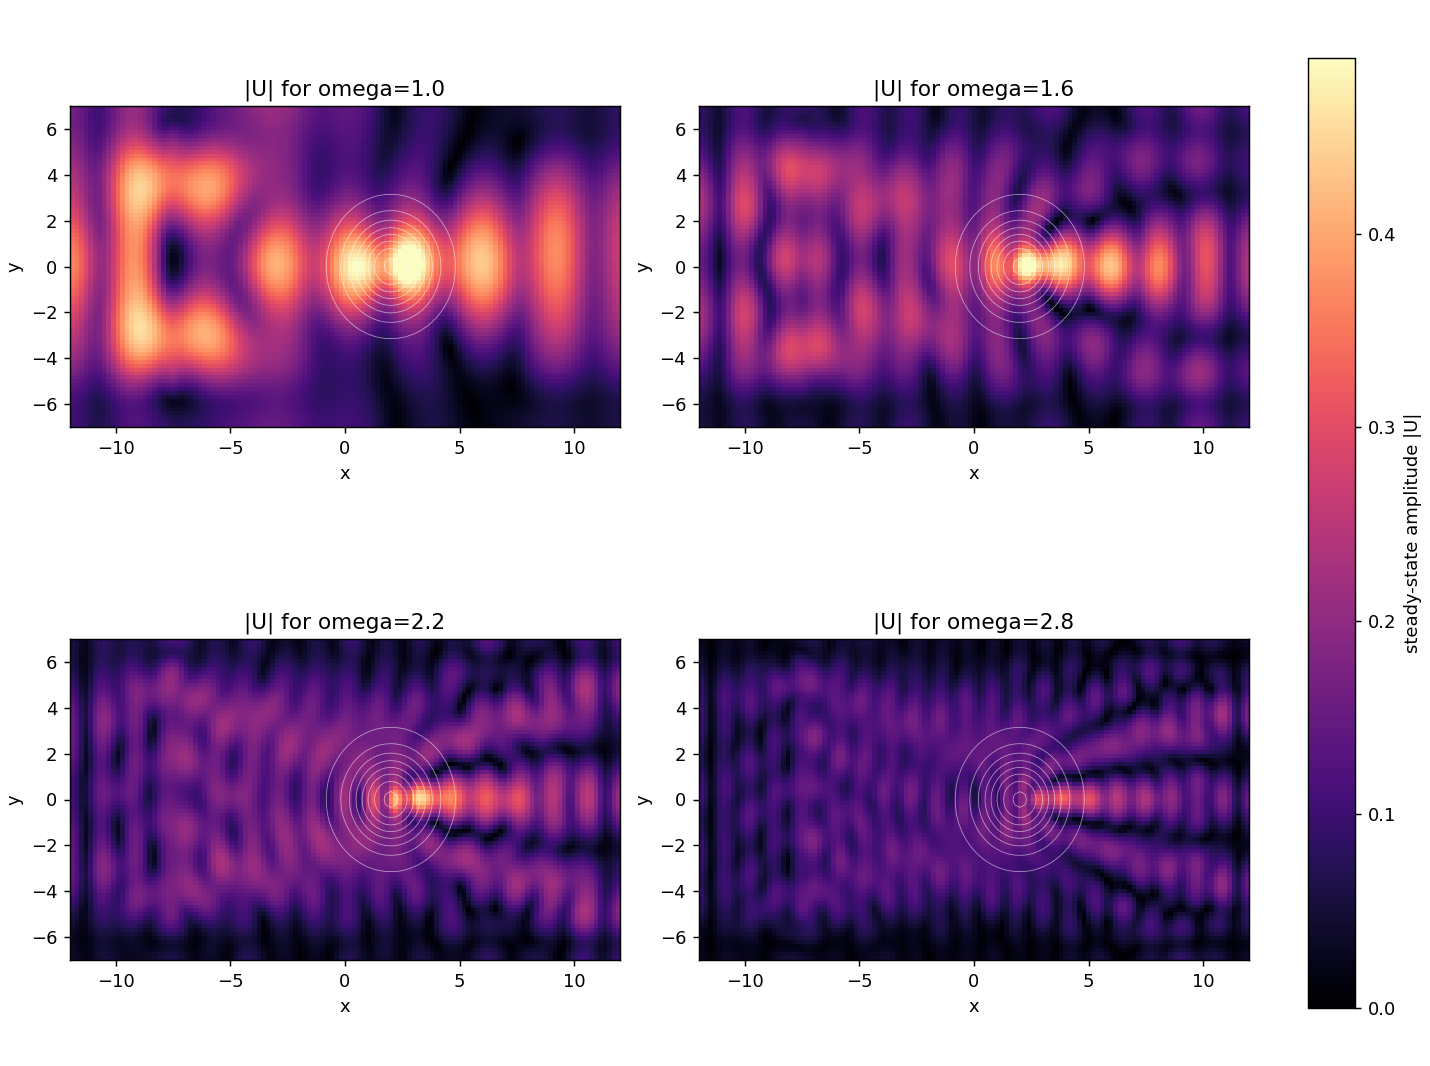

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.2), constrained_layout=True)
axes = axes.ravel()
amp_max = max(float(np.quantile(np.abs(sol.total), 0.995)) for sol in solutions)

for ax, sol in zip(axes, solutions):
    im = ax.imshow(np.abs(sol.total), extent=extent, cmap='magma', vmin=0.0, vmax=amp_max)
    ax.contour(grid.x, grid.y, medium.depth, colors='w', linewidths=0.45, alpha=0.55)
    ax.set_title(f'$|U|$ for $\omega={sol.omega:.1f}$')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes, shrink=0.9, label='steady-state amplitude $|U|$')
plt.show()



The amplitude plots already show a qualitative trend:

- at **lower frequency**, the field spreads more broadly behind the island,
- at **higher frequency**, the wake becomes more structured, with narrower lobes and clearer oscillatory fringes.

This is exactly the kind of transition one expects when the wavelength becomes comparable to, and then smaller than, the geometric size of the obstacle.


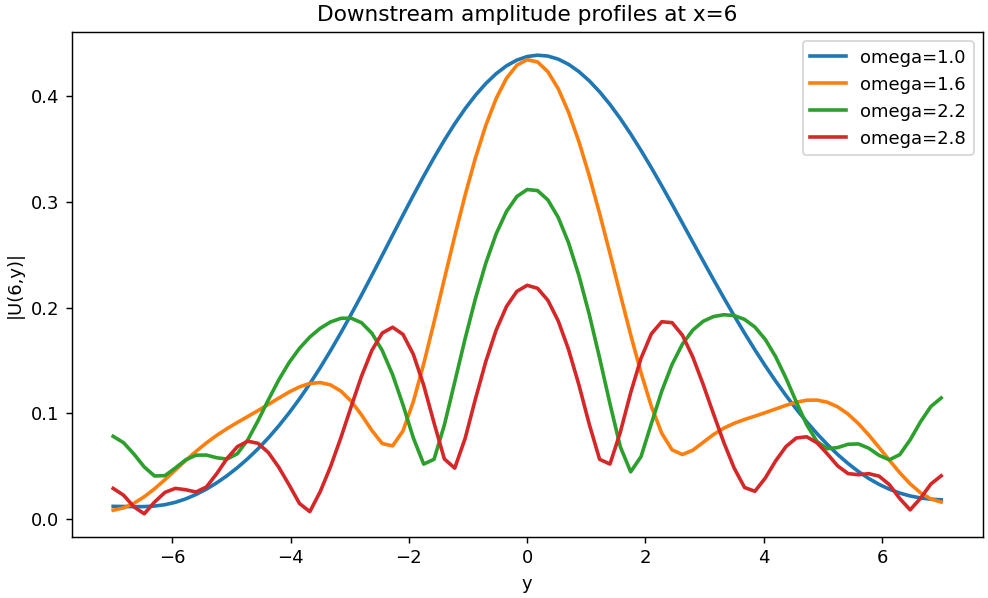

In [9]:

# A simple downstream diagnostic: amplitude on the vertical line x = 6.
fig, ax = plt.subplots(figsize=(7.6, 4.6), constrained_layout=True)
for sol in solutions:
    y_probe, profile = downstream_profile(sol, x_probe=6.0)
    ax.plot(y_probe, profile, linewidth=2.0, label=fr'$\omega={sol.omega:.1f}$')

ax.set_title('Downstream amplitude profiles at $x=6$')
ax.set_xlabel('y')
ax.set_ylabel(r'$|U(6,y)|$')
ax.legend()
plt.show()



The line plot gives a compact way to compare diffraction patterns.

- For small $\omega$, the downstream profile is comparatively broad.
- As $\omega$ increases, the energy concentrates into sharper oscillatory lobes.
- The change is not monotone in every pointwise sense, but the **spatial structure** becomes much finer.


In [10]:

freq_movie = workdir / 'steady_state_frequency_cycle.mp4'
if not freq_movie.exists():
    save_frequency_cycle_animation(solutions, freq_movie, nphase=20, fps=10, dpi=70)

display(Video(str(freq_movie), embed=True, html_attributes='controls loop'))


Your browser does not support the video tag.


## 5. Where does analysis show up?

This toy computation points toward several genuine analysis questions.

### Variable-coefficient wave propagation
The operator
$$
\partial_t^2 - \nabla\cdot(c(x,y)^2\nabla)
$$
is a variable-coefficient hyperbolic operator.  Energy estimates, well-posedness, and regularity all live here.

### High-frequency limits
When $\omega$ is large, one expects geometric-optics behavior: rays, eikonal equations, transport along characteristics, caustics, and shadow regions.

### Scattering theory
The steady-state problem is a variable-coefficient Helmholtz equation.  One can ask about outgoing solutions, resolvent bounds, trapped rays, and resonances.

### Inverse problems
Can one recover the bathymetry $H(x,y)$ from measured scattered waves?  That question leads toward inverse scattering and PDE-constrained optimization.



## 6. Ideas for student exploration

Here are some natural experiments to try next.

1. **Move the island** and see how the wake shifts.
2. **Change the island height**: shallower means slower, so the refraction effect strengthens.
3. **Increase the island radius** and compare “small obstacle vs large obstacle” scattering.
4. **Try much lower frequency** and see the field behave more like a broad diffracting wave.
5. **Try much higher frequency** and look for a more geometric-optics style shadow.
6. Replace the Gaussian island by **two islands** and look for interference.

The point is not only to make pictures: it is to build intuition for how coefficient geometry changes PDE solutions.



---

### Final remark

This notebook is deliberately simple: it is not a full ocean engineering code.  But it is already rich enough to show the bridge between

- a physical model,
- a PDE with variable coefficients,
- numerical approximation,
- and analysis-style questions about propagation, diffraction, and scattering.
